<a href="https://colab.research.google.com/github/KhusbuBubna123/BreastCancerDetection/blob/main/BreastCancer_ANN_1_MyVersion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [63]:
import pickle   # importing pickle for saving and loading machine learning models
import pandas as pd  # importing pandas for analyzing, cleaning, exploring, and manipulating data
from sklearn.model_selection import train_test_split  # importing train_test_split for spliting the data
from preprocess import *  # importing * for import all functions at once
from imblearn.over_sampling import SMOTE  # importing SMOTE for Balancing the Data
import numpy as np
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score,confusion_matrix
import sys
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import LabelEncoder

In [2]:
!pip install preprocess

In [35]:
'''from google.colab import drive
drive.mount('/content/drive')'''

"from google.colab import drive\ndrive.mount('/content/drive')"

In [36]:
df=pd.read_csv("BreastCancerDataset.csv")
df.head(8)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN
5,843786,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,...,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440,NaN
6,844359,M,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,...,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368,NaN
7,84458202,M,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,...,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510,NaN


In [37]:
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')

In [ ]:
'''from google.colab import drive
drive.mount('/content/drive')'''

"from google.colab import drive\ndrive.mount('/content/drive')"

In [41]:
df.isnull().sum() #Null values not present in dataset.

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


In [42]:
def remove_outlier(column):
  df=pd.read_csv("BreastCancerDataset.csv")
  # Calculate quartiles
  Q1 = df[column].quantile(0.25)
  Q3 = df[column].quantile(0.75)
  # Calculate IQR
  IQR = Q3 - Q1
  IQR
  # Define lower and upper bounds
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  # Remove outliers
  df=df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
  #df

In [43]:
import sys
import pickle
import pandas as pd
from sklearn.preprocessing import LabelEncoder

try:
    with open('/content/BreastCancerPreprocessor.pkl', "rb") as f:
        preprocessor = pickle.load(f)
    print("Preprocessor loaded successfully!")
except Exception as e:
    print(f"Failed to load preprocessor: {e}")

Preprocessor loaded successfully!


In [44]:
preprocessor

ColumnTransformer(transformers=[('Standard_scaler', StandardScaler(),
                                 ['radius_mean', 'texture_mean',
                                  'perimeter_mean', 'area_mean',
                                  'smoothness_mean', 'compactness_mean',
                                  'concavity_mean', 'concave points_mean',
                                  'symmetry_mean', 'fractal_dimension_mean',
                                  'radius_se', 'texture_se', 'perimeter_se',
                                  'area_se', 'smoothness_se', 'compactness_se',
                                  'concavity_se', 'concave points_se',
                                  'symmetry_se', 'fractal_dimension_se',
                                  'radius_worst', 'texture_worst',
                                  'perimeter_worst', 'area_worst',
                                  'smoothness_worst', 'compactness_worst',
                                  'concavity_worst', 'concave points_worst',
                                  'symmetry_worst',
                                  'fractal_dimension_worst'])])

In [45]:
X=df.drop(columns=['diagnosis','id'],axis=1)
Y=df['diagnosis']

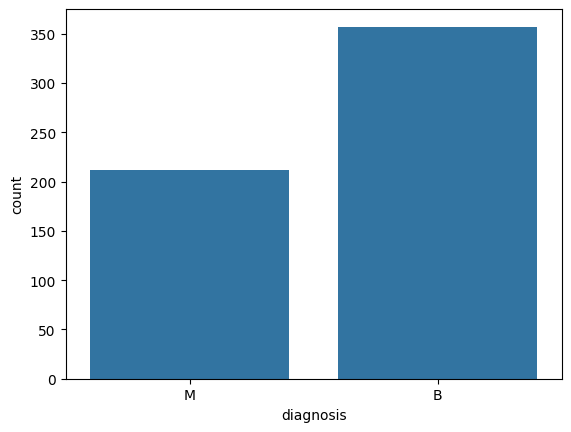

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x=Y)
plt.show()

In [47]:
le = LabelEncoder()
Y = le.fit_transform(df['diagnosis'])
Y

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0,
       0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,

In [48]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,
                                test_size=0.2,random_state=42)

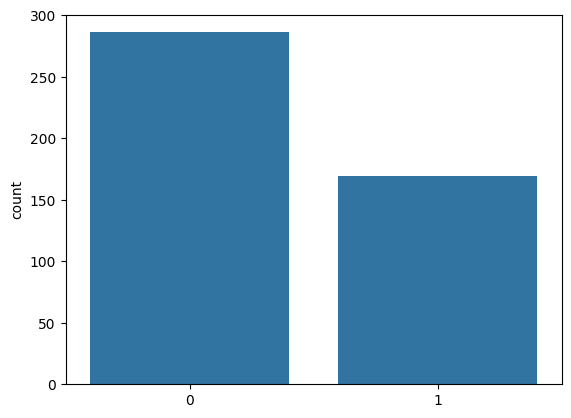

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x=Y_train)
plt.show()

In [50]:
X_train

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
68,9.029,17.33,58.79,250.5,0.10660,0.14130,0.31300,0.04375,0.2111,0.08046,...,22.65,65.50,324.7,0.14820,0.43650,1.25200,0.17500,0.4228,0.11750,NaN
181,21.090,26.57,142.70,1311.0,0.11410,0.28320,0.24870,0.14960,0.2395,0.07398,...,33.48,176.50,2089.0,0.14910,0.75840,0.67800,0.29030,0.4098,0.12840,NaN
63,9.173,13.86,59.20,260.9,0.07721,0.08751,0.05988,0.02180,0.2341,0.06963,...,19.23,65.59,310.1,0.09836,0.16780,0.13970,0.05087,0.3282,0.08490,NaN
248,10.650,25.22,68.01,347.0,0.09657,0.07234,0.02379,0.01615,0.1897,0.06329,...,35.19,77.98,455.7,0.14990,0.13980,0.11250,0.06136,0.3409,0.08147,NaN
60,10.170,14.88,64.55,311.9,0.11340,0.08061,0.01084,0.01290,0.2743,0.06960,...,17.45,69.86,368.6,0.12750,0.09866,0.02168,0.02579,0.3557,0.08020,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,8.888,14.64,58.79,244.0,0.09783,0.15310,0.08606,0.02872,0.1902,0.08980,...,15.67,62.56,284.4,0.12070,0.24360,0.14340,0.04786,0.2254,0.10840,NaN
106,11.640,18.33,75.17,412.5,0.11420,0.10170,0.07070,0.03485,0.1801,0.06520,...,29.26,85.51,521.7,0.16880,0.26600,0.28730,0.12180,0.2806,0.09097,NaN
270,14.290,16.82,90.30,632.6,0.06429,0.02675,0.00725,0.00625,0.1508,0.05376,...,20.65,94.44,684.6,0.08567,0.05036,0.03866,0.03333,0.2458,0.06120,NaN
435,13.980,19.62,91.12,599.5,0.10600,0.11330,0.11260,0.06463,0.1669,0.06544,...,30.80,113.90,869.3,0.16130,0.35680,0.40690,0.18270,0.3179,0.10550,NaN


In [51]:


Proprocessed_X_train = preprocessor.fit_transform(X_train)
Preprocessed_X_test=preprocessor.transform(X_test)
print(Proprocessed_X_train)

[[-1.44075296 -0.43531947 -1.36208497 ...  0.9320124   2.09724217
   1.88645014]
 [ 1.97409619  1.73302577  2.09167167 ...  2.6989469   1.89116053
   2.49783848]
 [-1.39998202 -1.24962228 -1.34520926 ... -0.97023893  0.59760192
   0.0578942 ]
 ...
 [ 0.04880192 -0.55500086 -0.06512547 ... -1.23903365 -0.70863864
  -1.27145475]
 [-0.03896885  0.10207345 -0.03137406 ...  1.05001236  0.43432185
   1.21336207]
 [-0.54860557  0.31327591 -0.60350155 ... -0.61102866 -0.3345212
  -0.84628745]]


In [52]:
smote=SMOTE()
X_train_smote,Y_train_smote=smote.fit_resample(Proprocessed_X_train,Y_train)

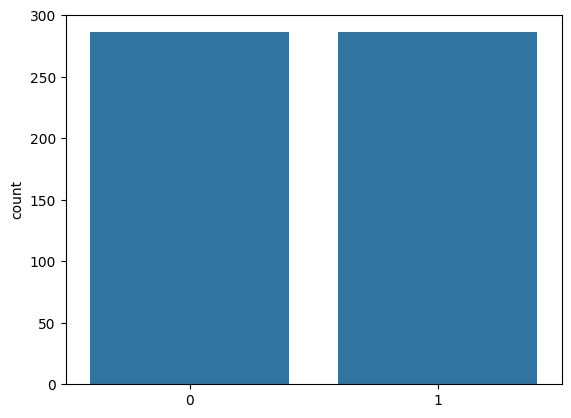

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x=Y_train_smote)
plt.show()

In [64]:
model = MLPClassifier(hidden_layer_sizes=(50,3),
                      learning_rate_init=0.1,
                      max_iter=100,
                      random_state=42)
model.fit(Proprocessed_X_train,Y_train)
Y_Predict_proba = model.predict_proba(Preprocessed_X_test)
# predicting the probability of class
Y_Predict_proba

array([[9.99954077e-01, 4.59234459e-05],
       [1.64813037e-02, 9.83518696e-01],
       [1.64813037e-02, 9.83518696e-01],
       [1.00000000e+00, 1.25655046e-33],
       [1.00000000e+00, 2.09495853e-38],
       [1.64813037e-02, 9.83518696e-01],
       [1.64813037e-02, 9.83518696e-01],
       [1.64813037e-02, 9.83518696e-01],
       [9.99993322e-01, 6.67758768e-06],
       [1.00000000e+00, 6.55723801e-23],
       [9.53448369e-01, 4.65516309e-02],
       [1.64813037e-02, 9.83518696e-01],
       [1.00000000e+00, 7.76883527e-11],
       [1.64813037e-02, 9.83518696e-01],
       [1.00000000e+00, 2.64181523e-21],
       [1.64813037e-02, 9.83518696e-01],
       [1.00000000e+00, 4.23376153e-20],
       [1.00000000e+00, 3.93019864e-27],
       [1.00000000e+00, 3.54759807e-40],
       [1.64813037e-02, 9.83518696e-01],
       [1.00000000e+00, 1.70232535e-10],
       [1.00000000e+00, 3.10474638e-11],
       [1.64813037e-02, 9.83518696e-01],
       [1.00000000e+00, 6.92558619e-21],
       [1.000000

In [65]:
Y_Predict = model.predict(Preprocessed_X_test)
Y_Predict

array([0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0,
       1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 1])

In [66]:
Y_Pred_categorical = le.inverse_transform(Y_Predict)
print("Decoded:", Y_Pred_categorical)

Decoded: ['B' 'M' 'M' 'B' 'B' 'M' 'M' 'M' 'B' 'B' 'B' 'M' 'B' 'M' 'B' 'M' 'B' 'B'
 'B' 'M' 'B' 'B' 'M' 'B' 'B' 'B' 'B' 'B' 'B' 'M' 'B' 'B' 'B' 'B' 'B' 'B'
 'M' 'B' 'M' 'B' 'B' 'M' 'B' 'B' 'M' 'B' 'B' 'B' 'B' 'B' 'M' 'M' 'M' 'B'
 'B' 'B' 'B' 'M' 'M' 'B' 'B' 'M' 'M' 'B' 'B' 'B' 'M' 'M' 'B' 'B' 'M' 'M'
 'B' 'M' 'B' 'B' 'B' 'M' 'B' 'B' 'M' 'B' 'M' 'M' 'M' 'M' 'M' 'M' 'B' 'B'
 'B' 'M' 'B' 'B' 'B' 'B' 'M' 'M' 'B' 'M' 'M' 'B' 'M' 'M' 'B' 'B' 'B' 'M'
 'B' 'B' 'M' 'B' 'B' 'M']


In [67]:
print("Test accuracy :",accuracy_score(Y_test,Y_Predict))

Test accuracy : 0.9649122807017544


In [69]:
ConfusionMatrix = pd.DataFrame(
    confusion_matrix(Y_test,Y_Predict),
    index=['Actual Benign', 'Actual Malignant'],
    columns=['Predicted Benign', 'Predicted Malignant']
)

# Display the DataFrame
ConfusionMatrix

#pd.crosstab(Y_test,Y_Predict)

,Predicted Benign,Predicted Malignant
Actual Benign,68,3
Actual Malignant,1,42
